# Dataset Exploration 

In [1]:
# Systems and Files libraries
import os
import re
from pathlib import Path

# Pandas and numpy
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


## Merge and Prep Data

In [2]:
#load data from .parquet to pandas dataframes
weather_path = Path("example_data/weather_EDDF_LGTS.parquet")
flights_path = Path("example_data/flights_utc.parquet")

w_df = pd.read_parquet(weather_path, engine="pyarrow")
f_df = pd.read_parquet(flights_path, engine="pyarrow")

print(w_df.info())
print(f_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 52656 entries, 0 to 52655
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   time                        52656 non-null  datetime64[us, UTC]
 1   temperature_2m              52656 non-null  float64            
 2   relative_humidity_2m        52656 non-null  int64              
 3   dew_point_2m                52656 non-null  float64            
 4   precipitation               52656 non-null  float64            
 5   weather_code                52656 non-null  int64              
 6   pressure_msl                52656 non-null  float64            
 7   cloud_cover_low             52656 non-null  int64              
 8   cloud_cover_high            52656 non-null  int64              
 9   visibility                  52656 non-null  float64            
 10  wind_speed_10m              52656 non-null  float64            
 11  

In [3]:

# Work on copies

flights = f_df.copy()
weather = w_df.copy()

# A timestamp bug occurred in the flights dataset
# It was identified when data type casting to different timestamp formats (ns vs us) resulted in dates set in 1970 when they were expected to be in 2023
# The 1970 bug is caused by unix timestamps being referenced to the epoch (1970-01-01 00:00:00 UTC) and can occur when timestamps are not properly handled or converted
# To avoid this: ensure that all datetime columns are parsed as timezone-aware UTC datetimes.


# We do this for both dataframes to ensure everything lines up correctly and avoids any potential issues with timezone differences or misalignment of timestamps

for col in ["firstSeen", "lastSeen", "firstSeen_hourly_utc", "lastSeen_hourly_utc"]:
    if col in flights.columns:
        flights[col] = pd.to_datetime(flights[col], utc=True)


if "time" in weather.columns:
    weather["time"] = pd.to_datetime(weather["time"], utc=True)


# Converting to strings completely strips out internal sub-second precision and unit differences (ns vs us) 
# between your data files is now eliminated, and the merge keys will match correctly

flights["dep_merge_key"] = flights["firstSeen_hourly_utc"].dt.strftime("%Y-%m-%d %H:00")
flights["arr_merge_key"] = flights["lastSeen_hourly_utc"].dt.strftime("%Y-%m-%d %H:00")
weather["weather_merge_key"] = weather["time"].dt.strftime("%Y-%m-%d %H:00")

# The weather features we want to merge into the flights dataframe are defined in a list for easy reference and manipulation
weather_features = [
    "temperature_2m", 
    "relative_humidity_2m", 
    "dew_point_2m", 
    "precipitation",
    "weather_code", 
    "pressure_msl", 
    "cloud_cover_low", 
    "cloud_cover_high",
    "visibility", 
    "wind_speed_10m", 
    "wind_speed_180m", 
    "wind_direction_10m",
    "wind_direction_180m", 
    "cape", 
    "geopotential_height_850hPa",
]

# Verify that there are no duplicates in the weather dataframe based on the airport and weather_merge_key columns
weather_duplicates = weather.duplicated(subset=["airport", "weather_merge_key"]).sum()

print("=" * 70)
print("WEATHER KEY VALIDATION")
print("=" * 70)
print(f"Duplicate airport + time combinations: {weather_duplicates}")

if weather_duplicates > 0:
    print("Dropping duplicates found in historical weather source arrays...")
    weather = weather.drop_duplicates(subset=["airport", "weather_merge_key"], keep="first")




# MERGE WEATHER DATA INTO FLIGHTS DATAFRAME ------------------------------------------------------------------------------------------------

# For this size of dataset, we could do two sequential merges: one for departure weather and one for arrival weather
# However, larger datasets may require a more memory-efficient approach, such as dual-indexed joins

# Main idea: 
# Our left table is flights 
# And we lookup through weather using a MultiIndex of (airport, weather_merge_key) to find the corresponding weather features for both departure and arrival airports
# The index allows really quick lookups

# Why merge and not join?
# Merge allows us to match regular columns (left_on) directly to the weather index (right_index=True)
# This avoids having to constantly set and reset indices on the flights dataframe, keeping the original column layout intact


# Prepare base weather index -> create a multiindex of airport and weather_merge_key, and select only the weather features we want to merge into the flights dataframe
w_indexed = weather.set_index(["airport", "weather_merge_key"])[
    weather_features
]

# Left join departure weather on ("airport", "weather_merge_key") == ("estDepartureAirport", "dep_merge_key")
# Right_index=True tells pandas to match the flights keys directly against the fast weather MultiIndex
# This retains the speed of index lookups while keeping the original flight column order intact
flights = flights.merge(
    w_indexed.add_prefix("dep_"),
    left_on=["estDepartureAirport", "dep_merge_key"],
    right_index=True,
    how="left",
)

# Left join arrival weather on ("airport", "weather_merge_key") == ("estArrivalAirport", "arr_merge_key")
# Right_index=True leverages the same pre-built weather lookup index for maximum memory efficiency
flights = flights.merge(
    w_indexed.add_prefix("arr_"),
    left_on=["estArrivalAirport", "arr_merge_key"],
    right_index=True,
    how="left",
)

# ---------------------------------------------------------------------------------------------------------------------------

# Validate the merge by checking for missing weather data in the flights dataframe
print()
print("=" * 70)
print("MERGE VALIDATION")
print("=" * 70)
print(f"Final number of flights: {len(flights)}")

missing_departure_weather = flights["dep_temperature_2m"].isna().sum()
missing_arrival_weather = flights["arr_temperature_2m"].isna().sum()

print(f"Flights missing departure weather: {missing_departure_weather} / {len(flights)}")
print(f"Flights missing arrival weather:   {missing_arrival_weather} / {len(flights)}")

print()
print("=" * 70)
print("FINAL DATASET INFO SUMMARY")
print("=" * 70)
flights.info()


WEATHER KEY VALIDATION
Duplicate airport + time combinations: 0

MERGE VALIDATION
Final number of flights: 2081
Flights missing departure weather: 0 / 2081
Flights missing arrival weather:   0 / 2081

FINAL DATASET INFO SUMMARY
<class 'pandas.DataFrame'>
RangeIndex: 2081 entries, 0 to 2080
Data columns (total 48 columns):
 #   Column                            Non-Null Count  Dtype              
---  ------                            --------------  -----              
 0   icao24                            2081 non-null   str                
 1   firstSeen                         2081 non-null   datetime64[ms, UTC]
 2   estDepartureAirport               2081 non-null   str                
 3   lastSeen                          2081 non-null   datetime64[ms, UTC]
 4   estArrivalAirport                 2081 non-null   str                
 5   callsign                          2081 non-null   str                
 6   estDepartureAirportHorizDistance  2081 non-null   float64            
 

In [4]:

# Ensure absolute chronological sorting
flights = flights.sort_values("firstSeen").reset_index(drop=True)

# Extract base flight duration and drop missing values
flights["flight_duration"] = (
    flights["lastSeen"] - flights["firstSeen"]
).dt.total_seconds() / 60.0
flights = flights.dropna(subset=["flight_duration"])

# --- OUTLIER REMOVAL RULE ---
# Create a mask for the specific Spring 2025 extreme outlier (> 300 minutes)
# This removes the data logging error before it splits into Fold 1's test set.  
# it is highly unlikely that the flight duration would exceed 5 hours, transpoder data logging error is likely the cause of this extreme outlier.
outlier_mask = (
    (flights["firstSeen"] >= "2025-04-01")
    & (flights["firstSeen"] <= "2025-07-01")
    & (flights["flight_duration"] > 300)
)

print(f"Removing {outlier_mask.sum()} extreme outlier row(s) from Spring 2025...")
flights = flights[~outlier_mask].reset_index(drop=True)
# ----------------------------

# Create route identifier 
if "route" not in flights.columns:
    flights["route"] = (
        flights["estDepartureAirport"].astype(str)
        + "_"
        + flights["estArrivalAirport"].astype(str)
    )

# Feature Engineering
flights["airline"] = flights["callsign"].str[:3]
flights["hour_of_day"] = flights["firstSeen"].dt.hour
flights["month"] = flights["firstSeen"].dt.month

# Keep a clean reference of flight dates for TimeSeriesSplit visualization/logging
flights["flight_date_parsed"] = pd.to_datetime(flights["firstSeen"].dt.date)

# Define Columns to Drop (Keep raw variables needed for loop-level target calculation)
cols_to_drop = [
    "icao24",
    "firstSeen",
    "lastSeen",
    "estDepartureAirport",
    "estArrivalAirport",
    "callsign",
    "flight_date",
    "firstSeen_hourly_utc",
    "lastSeen_hourly_utc",
    "dep_merge_key",
    "arr_merge_key",
    "departureAirportCandidatesCount",
    "arrivalAirportCandidatesCount",
    "estDepartureAirportHorizDistance",
    "estDepartureAirportVertDistance",
    "estArrivalAirportHorizDistance",
    "estArrivalAirportVertDistance",
]

# Drop useless columns
X_raw = flights.drop(columns=[c for c in cols_to_drop if c in flights.columns])

# Separate Categorical and Numerical tracking lists
categorical_cols = ["airline"]
numeric_cols = [
    col
    for col in X_raw.columns
    if col not in categorical_cols
    and col not in ["flight_duration", "route", "flight_date_parsed"]
]

# Drop low variance/constant features globally based on independent columns
constant_cols = [
    c
    for c in numeric_cols
    if X_raw[c].nunique() <= 1 and c not in ["hour_of_day", "month"]
]
if constant_cols:
    X_raw = X_raw.drop(columns=constant_cols)
    numeric_cols = [c for c in numeric_cols if c not in constant_cols]


Removing 1 extreme outlier row(s) from Spring 2025...


In [5]:
#print(flights.shape)
#print(flights.head())
print(X.info())


NameError: name 'X' is not defined

In [ ]:
print(X[numeric_cols].describe().T)

                                 count          mean           std     min  \
dep_temperature_2m              2081.0     15.908361      8.512240    -6.5   
dep_relative_humidity_2m        2081.0     64.152331     20.687937    12.0   
dep_dew_point_2m                2081.0      8.117251      5.823528   -11.6   
dep_precipitation               2081.0      0.066699      0.409010     0.0   
dep_weather_code                2081.0     12.300817     23.184624     0.0   
dep_pressure_msl                2081.0   1016.241903      8.343937   977.6   
dep_cloud_cover_low             2081.0     42.002883     39.630092     0.0   
dep_cloud_cover_high            2081.0     35.837578     44.807082     0.0   
dep_visibility                  2081.0  37067.842383  22294.818672    60.0   
dep_wind_speed_10m              2081.0      8.496060      4.280951     0.0   
dep_wind_speed_180m             2081.0     18.493753     11.142085     0.0   
dep_wind_direction_10m          2081.0    176.765017     93.6852

In [ ]:
print(flights.describe(include="all"))

        icao24                         firstSeen estDepartureAirport  \
count     2081                              2081                2081   
unique     188                               NaN                   1   
top     4691c1                               NaN                EDDF   
freq       106                               NaN                2081   
mean       NaN  2025-03-27 10:40:54.607000+00:00                 NaN   
min        NaN         2023-07-31 10:25:08+00:00                 NaN   
25%        NaN         2024-07-13 09:32:22+00:00                 NaN   
50%        NaN         2025-04-30 12:51:32+00:00                 NaN   
75%        NaN         2025-12-06 09:26:53+00:00                 NaN   
max        NaN         2026-07-31 19:07:09+00:00                 NaN   
std        NaN                               NaN                 NaN   

                                lastSeen estArrivalAirport  callsign  \
count                               2081              2081     

In [ ]:
print(X.describe(include="all"))

        icao24  dep_temperature_2m  dep_relative_humidity_2m  \
count     2081         2081.000000               2081.000000   
unique     188                 NaN                       NaN   
top     4691c1                 NaN                       NaN   
freq       106                 NaN                       NaN   
mean       NaN           15.908361                 64.152331   
std        NaN            8.512240                 20.687937   
min        NaN           -6.500000                 12.000000   
25%        NaN            9.700000                 47.000000   
50%        NaN           16.100000                 65.000000   
75%        NaN           22.200000                 83.000000   
max        NaN           40.700000                100.000000   

        dep_dew_point_2m  dep_precipitation  dep_weather_code  \
count        2081.000000        2081.000000       2081.000000   
unique               NaN                NaN               NaN   
top                  NaN            

In [ ]:
# Compute correlation matrix
corr_matrix = X[numeric_cols].corr()

# Unstack, remove self-correlation, and find absolute highest relationships
corr_pairs = corr_matrix.unstack()
sorted_pairs = corr_pairs.sort_values(kind="quicksort", ascending=False)

# Filter out the 1.0 correlations (diagonal) and avoid duplicate pairs (A-B vs B-A)
unique_important_pairs = sorted_pairs[abs(sorted_pairs) < 1.0].drop_duplicates()

print("--- Top 10 Strongest Positive Correlations ---")
print(unique_important_pairs[unique_important_pairs > 0].head(10))

print("\n--- Top 10 Strongest Negative Correlations ---")
print(unique_important_pairs[unique_important_pairs < 0].tail(10))


--- Top 10 Strongest Positive Correlations ---
dep_wind_direction_180m         dep_wind_direction_10m            0.947328
dep_pressure_msl                dep_geopotential_height_850hPa    0.861995
dep_wind_speed_10m              dep_wind_speed_180m               0.836066
arr_wind_speed_10m              arr_wind_speed_180m               0.829968
arr_temperature_2m              dep_temperature_2m                0.747586
dep_temperature_2m              dep_dew_point_2m                  0.731190
arr_geopotential_height_850hPa  arr_pressure_msl                  0.711408
arr_wind_direction_10m          arr_wind_direction_180m           0.706458
dep_cloud_cover_low             dep_relative_humidity_2m          0.687192
arr_temperature_2m              dep_dew_point_2m                  0.676209
dtype: float64

--- Top 10 Strongest Negative Correlations ---
arr_temperature_2m        arr_cloud_cover_low        -0.441703
arr_wind_direction_10m    hour_of_day                -0.452242
dep_temperatur

## Target Examination

In [ ]:
print(y.describe())

count    2081.000000
mean        0.477831
std         9.672369
min       -22.066667
25%        -3.816667
50%         0.000000
75%         4.016667
max       335.366667
Name: time_anomaly, dtype: float64


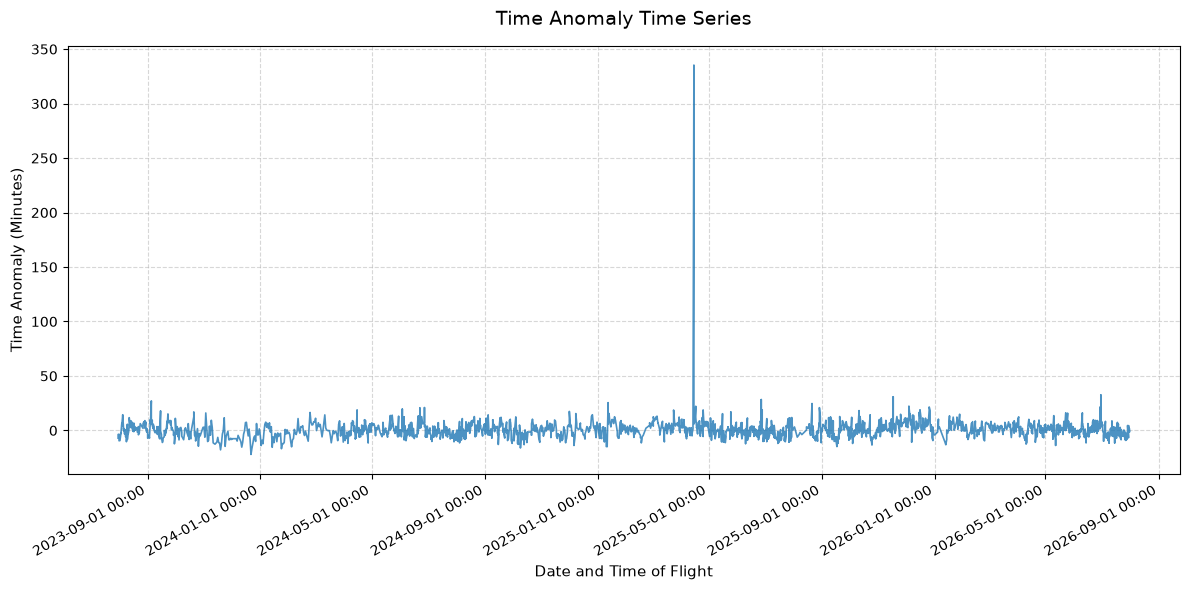

In [ ]:

df = pd.DataFrame({
    'flight_date': flights['flight_date'].astype(str).values,
    'value': flights['time_anomaly'].values,
    'airline': flights['airline'].values
})


df['timestamp'] = pd.to_datetime(df['flight_date'])

# Sort chronologically and set as index
df = df.sort_values('timestamp')
df.set_index('timestamp', inplace=True)


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['value'], linestyle='-', linewidth=1.2, color='#1f77b4', alpha=0.8)


plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.gcf().autofmt_xdate() # Auto-rotate labels


plt.title('Time Anomaly Time Series', fontsize=14, pad=15)
plt.xlabel('Date and Time of Flight', fontsize=11)
plt.ylabel('Time Anomaly (Minutes)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# 7. Display
plt.show()



In [ ]:
spring_2025_df = df[(df['flight_date'] >= '2025-04-01') & (df['flight_date'] <= '2025-07-01')]
print(spring_2025_df[spring_2025_df['value'] > 300])


           flight_date       value airline
timestamp                                 
2025-04-15  2025-04-15  335.366667     DLH


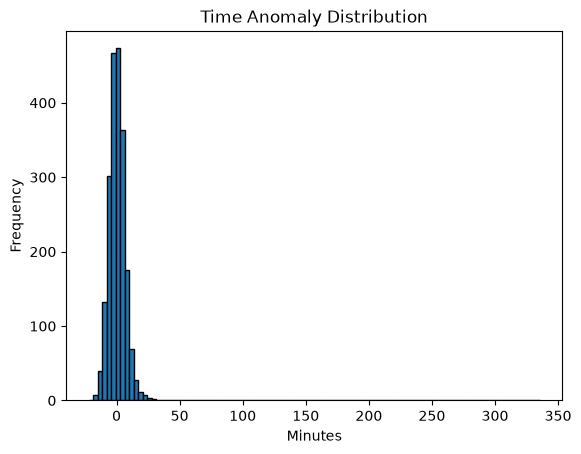

In [ ]:
# Plot the distribution directly from the pandas Series
flights["time_anomaly"].plot(kind="hist", bins=100, edgecolor="black")

# Add labels and titles
plt.title("Time Anomaly Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

# Display the plot
plt.show()



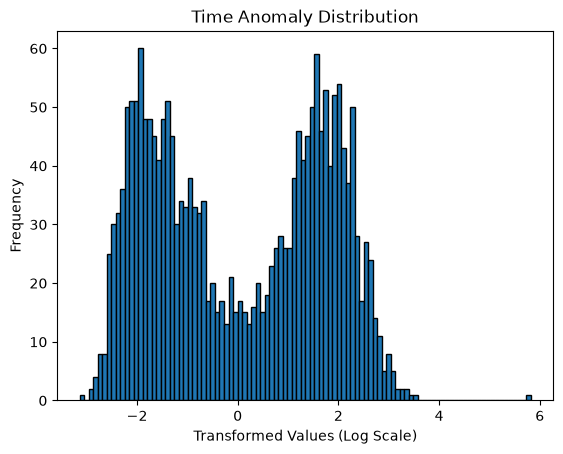

In [ ]:
time_anomaly_vals = flights["time_anomaly"]
# Apply the symmetric log transformation using NumPy vectorization
transformed_vals = np.sign(time_anomaly_vals) * np.log1p(abs(time_anomaly_vals))
# Note: transformation is increasing monotonic 
# -> we can transform it easily back to the original scale by applying the inverse transformation

# Plot the distribution directly from the pandas Series
transformed_vals.plot(kind="hist", bins=100, edgecolor="black")

# Add labels and titles
plt.title("Time Anomaly Distribution")
plt.xlabel("Transformed Values (Log Scale)")
plt.ylabel("Frequency")

# Display the plot
plt.show()


### Trying to explain the bimodal distribution of the target value

#### Color Code by Month

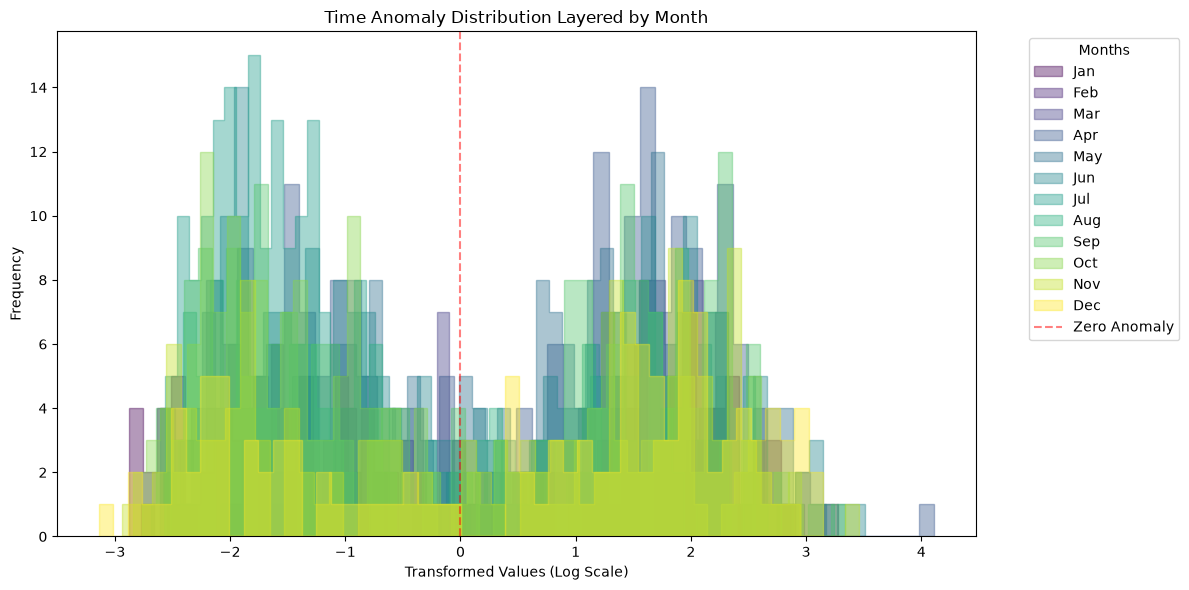

In [ ]:


# 1. Parse timestamps and extract the month
timestamps = pd.to_datetime(flights["flight_date"].astype(str))
months = timestamps.dt.month  # Extracts numbers 1-12

# 2. Process the values
time_anomaly_vals = flights["time_anomaly"].clip(-60, 60)
transformed_vals = np.sign(time_anomaly_vals) * np.log1p(abs(time_anomaly_vals))

# 3. Combine transformed data and months into a temporary DataFrame for grouping
plot_df = pd.DataFrame({"values": transformed_vals, "month": months})

# 4. Set up the plot layout
plt.figure(figsize=(12, 6))

# Define a color palette or use a colormap to easily distinguish seasons
# Summer months (6, 7, 8) will stand out if using a sequential map like 'plasma' or 'viridis'
colors = plt.cm.viridis(np.linspace(0, 1, 12))

# 5. Loop through each month and overlay the histograms
# Using 'histtype="step"' or 'alpha' makes overlapping distributions visible
for month_num in sorted(plot_df["month"].unique()):
    month_data = plot_df[plot_df["month"] == month_num]["values"]

    # Convert month number to a readable abbreviation for the legend
    month_name = pd.to_datetime(f"2026-{month_num}-01").strftime("%b")

    plt.hist(
        month_data,
        bins=50,  # Lowered slightly from 100 so individual months don't look too sparse
        alpha=0.4,  # Transparency lets you see overlapping modes
        edgecolor=colors[month_num - 1],
        color=colors[month_num - 1],
        label=month_name,
        histtype="stepfilled",  # Fills bars lightly while keeping edges sharp
    )

# Add layout details to expose the bimodal shift
plt.title("Time Anomaly Distribution Layered by Month")
plt.xlabel("Transformed Values (Log Scale)")
plt.ylabel("Frequency")
plt.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="Zero Anomaly")
plt.legend(title="Months", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

# seasons are spread out, there is no pattern of seasonal effects here

#### Color Code by Hour of Day

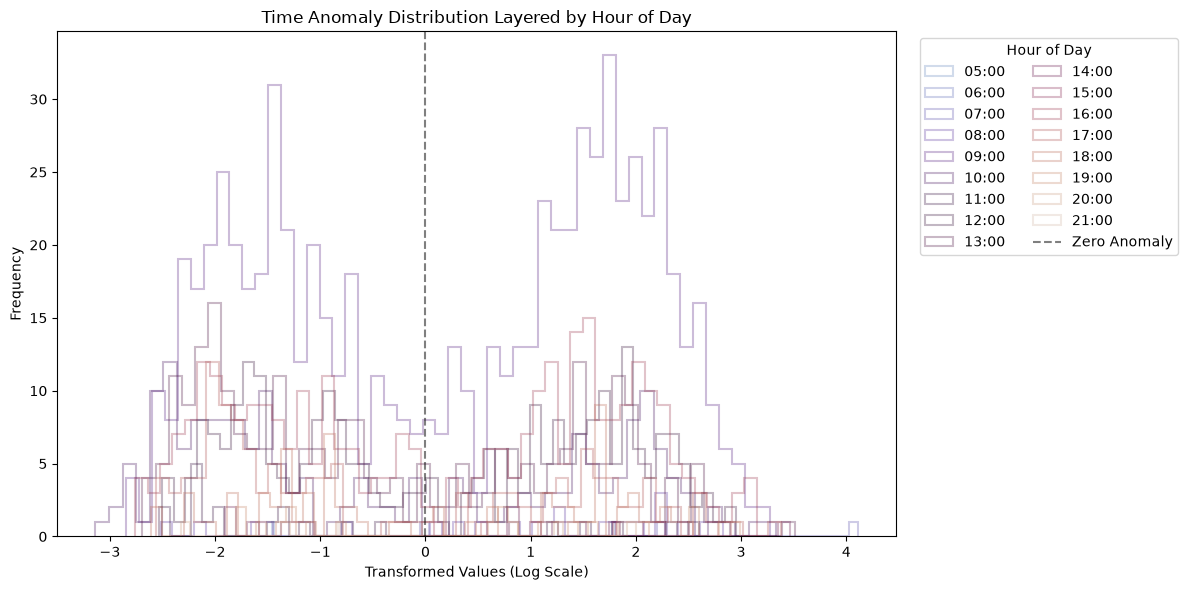

In [ ]:


# 1. Grab the hour column directly (no string parsing needed)
hours = flights["hour_of_day"]

# 2. Process the anomaly values
time_anomaly_vals = flights["time_anomaly"].clip(-60, 60)
transformed_vals = np.sign(time_anomaly_vals) * np.log1p(abs(time_anomaly_vals))

# 3. Combine into a temporary DataFrame for grouping
plot_df = pd.DataFrame({"values": transformed_vals, "hour": hours})

# 4. Set up the plot layout
plt.figure(figsize=(12, 6))

# Use a cyclic colormap to naturally transition from night to day to night
colors = plt.cm.twilight(np.linspace(0, 1, 24))

# 5. Loop through each unique hour present in your data
for hour_num in sorted(plot_df["hour"].unique()):
    hour_data = plot_df[plot_df["hour"] == hour_num]["values"]

    # Format the integer hour into a clean label (e.g., 9 -> "09:00")
    hour_label = f"{int(hour_num):02d}:00"

    plt.hist(
        hour_data,
        bins=50,
        alpha=0.3,  # Keeps overlapping curves readable
        edgecolor=colors[int(hour_num)],
        color=colors[int(hour_num)],
        label=hour_label,
        histtype="step",  # 'step' works best with 24 overlapping lines
        linewidth=1.5,
    )

# Add layout and regression context details
plt.title("Time Anomaly Distribution Layered by Hour of Day")
plt.xlabel("Transformed Values (Log Scale)")
plt.ylabel("Frequency")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5, label="Zero Anomaly")

# Place a 2-column legend outside the plot area
plt.legend(
    title="Hour of Day", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=2
)
plt.tight_layout()

plt.show()


#### Color Code by Airline

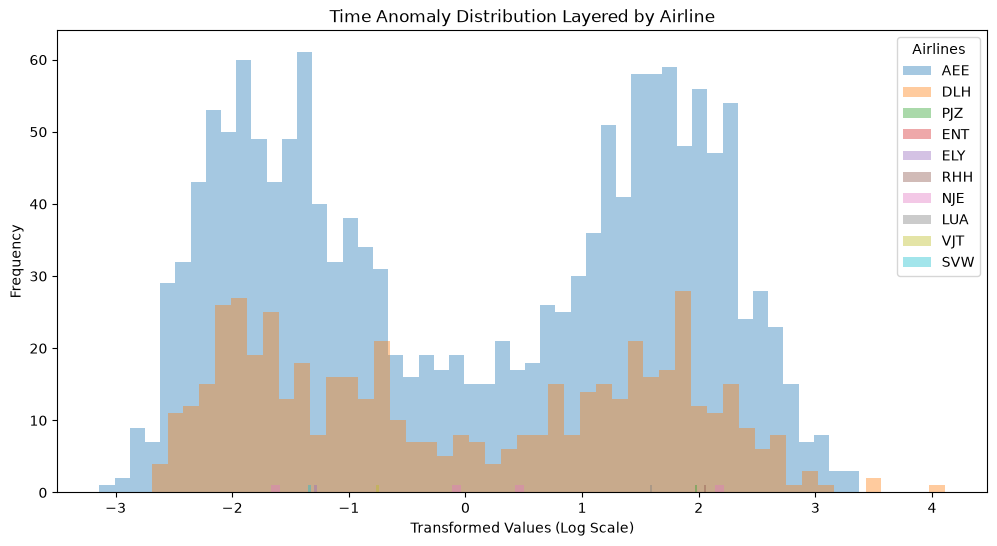

In [ ]:
# Process the anomaly values
time_anomaly_vals = flights["time_anomaly"].clip(-60, 60)
transformed_vals = np.sign(time_anomaly_vals) * np.log1p(abs(time_anomaly_vals))

plot_df = pd.DataFrame({"values": transformed_vals, "airline": flights["airline"]})

plt.figure(figsize=(12, 6))
# Loop through each airline to overlay their histograms
for airline_name in plot_df["airline"].unique():
    airline_data = plot_df[plot_df["airline"] == airline_name]["values"]

    plt.hist(
        airline_data,
        bins=50,
        alpha=0.4,
        label=str(airline_name),
        histtype="stepfilled",
    )

plt.title("Time Anomaly Distribution Layered by Airline")
plt.xlabel("Transformed Values (Log Scale)")
plt.ylabel("Frequency")
plt.legend(title="Airlines")
plt.show()


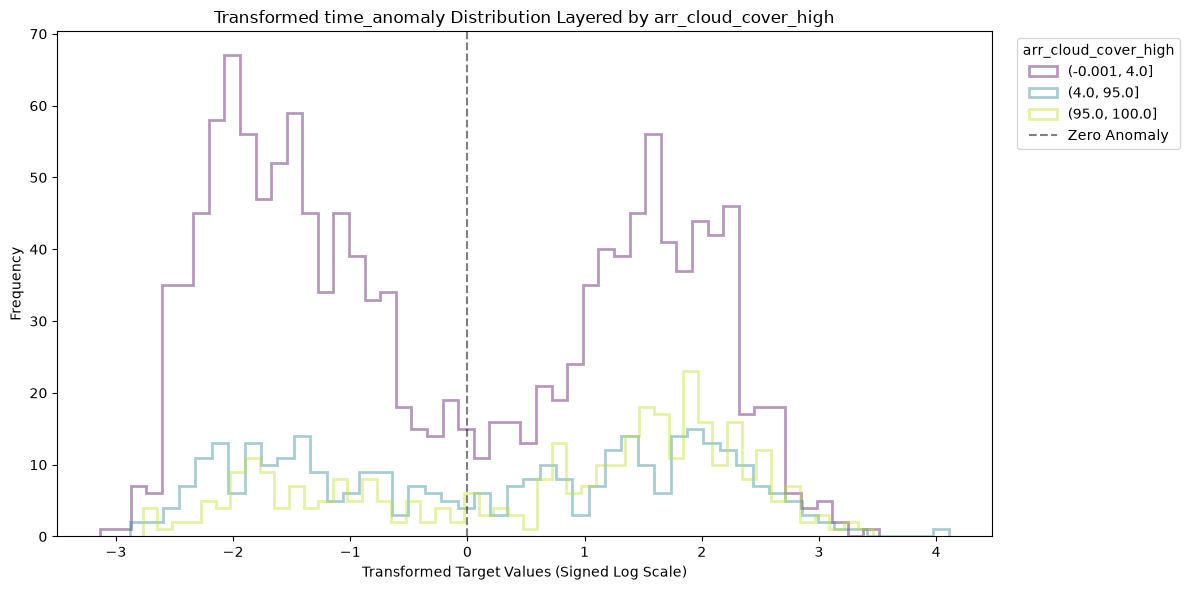

In [ ]:


# =====================================================================
# CONFIGURATION: Change these variables to swap features or targets
# =====================================================================
FEATURE_TO_EXAMINE = "arr_cloud_cover_high" #"dep_wind_direction_10m"
TARGET_COLUMN = "time_anomaly"

# CLIP_LIMITS: Set lower/upper limits to handle extreme outliers before logging
CLIP_LIMITS = (-60, 60)

# BINS_FOR_CONTINUOUS: Number of groups to create if the feature is numeric/continuous
BINS_FOR_CONTINUOUS = 6
# =====================================================================

# 1. Grab feature and process the target anomaly values
feature_vals = flights[FEATURE_TO_EXAMINE]
target_vals = flights[TARGET_COLUMN].clip(CLIP_LIMITS[0], CLIP_LIMITS[1])

# Apply your signed log transformation
transformed_target = np.sign(target_vals) * np.log1p(abs(target_vals))

# 2. Automatically handle Continuous vs Categorical feature groupings
# Check if feature is numeric and has many unique values (needs binning)
if pd.api.types.is_numeric_dtype(feature_vals) and feature_vals.nunique() > 10:
    # Use qcut for equal-sized groups (quantiles), or cut for equal intervals
    group_series = pd.qcut(feature_vals, q=BINS_FOR_CONTINUOUS, duplicates="drop")
else:
    # Use the categorical/discrete values directly
    group_series = feature_vals

# 3. Combine into a temporary DataFrame for grouping
plot_df = pd.DataFrame({"target": transformed_target, "group": group_series})

# Drop rows with missing values in either column
plot_df = plot_df.dropna()

# 4. Set up the plot layout
plt.figure(figsize=(12, 6))

unique_groups = sorted(plot_df["group"].unique())
num_groups = len(unique_groups)

# Use 'viridis', 'plasma', or 'twilight' depending on your color preference
colors = plt.cm.viridis(np.linspace(0, 0.9, num_groups))

# 5. Loop through each group and layer the histograms
for i, group_label in enumerate(unique_groups):
    group_data = plot_df[plot_df["group"] == group_label]["target"]

    plt.hist(
        group_data,
        bins=50,
        alpha=0.4,  # Slightly higher alpha since there are fewer groups than hours
        edgecolor=colors[i],
        color=colors[i],
        label=str(group_label),
        histtype="step",
        linewidth=2.0,
    )

# Add layout and regression context details
plt.title(
    f"Transformed {TARGET_COLUMN} Distribution Layered by {FEATURE_TO_EXAMINE}"
)
plt.xlabel("Transformed Target Values (Signed Log Scale)")
plt.ylabel("Frequency")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5, label="Zero Anomaly") 

# Place legend outside the plot area
plt.legend(
    title=FEATURE_TO_EXAMINE,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    ncol=1,
)
plt.tight_layout()

plt.show()
